# Задача №2: статистическое прогнозирование с StatsForecast

В ноутбуке строятся и сравниваются статистические модели прогнозирования ряда `Consumption`.

## 1. Импорт библиотек и настройки

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive, WindowAverage, SeasonalWindowAverage,
    ARIMA, Theta, AutoETS, AutoTheta, AutoARIMA
)
from statsforecast.utils import ConformalIntervals
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = Path('..')
REPORTS = ROOT / 'reports'
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = REPORTS / 'figures'
for p in [REPORTS, PROCESSED, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED / 'electricity_train.csv'
TEST_PATH = PROCESSED / 'electricity_test.csv'

DT = 'DateTime'
TARGET = 'Consumption'

ModuleNotFoundError: No module named 'statsforecast'

## 2. Загрузка подготовленных выборок 

In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df[DT] = pd.to_datetime(train_df[DT])
test_df[DT] = pd.to_datetime(test_df[DT])

train_df = train_df.sort_values(DT).reset_index(drop=True)
test_df = test_df.sort_values(DT).reset_index(drop=True)

print('train:', train_df[DT].min(), train_df[DT].max(), train_df.shape)
print('test:', test_df[DT].min(), test_df[DT].max(), test_df.shape)

train_df.head()

train: 2019-01-01 00:00:00 2023-03-14 13:00:00 (36806, 16)
test: 2023-03-14 14:00:00 2024-03-31 23:00:00 (9202, 16)


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,dayofweek,month,is_weekend,year,split
0,2019-01-01 00:00:00,6352.0,6527.0,1395.0,79.0,1383.0,1896.0,1744.0,0.0,30.0,0,1,1,0,2019,train
1,2019-01-01 01:00:00,6116.0,5701.0,1393.0,96.0,1112.0,1429.0,1641.0,0.0,30.0,1,1,1,0,2019,train
2,2019-01-01 02:00:00,5873.0,5676.0,1393.0,142.0,1030.0,1465.0,1616.0,0.0,30.0,2,1,1,0,2019,train
3,2019-01-01 03:00:00,5682.0,5603.0,1397.0,191.0,972.0,1455.0,1558.0,0.0,30.0,3,1,1,0,2019,train
4,2019-01-01 04:00:00,5557.0,5454.0,1393.0,159.0,960.0,1454.0,1458.0,0.0,30.0,4,1,1,0,2019,train


## 3. Формат для StatsForecast

In [ ]:
model_train = train_df.tail(24 * 60).copy()
test_horizon = test_df.head(168).copy()

Y_train = model_train[[DT, TARGET]].rename(columns={DT: 'ds', TARGET: 'y'})
Y_train.insert(0, 'unique_id', 'electricity')
Y_train.head()

,unique_id,ds,y
35366,electricity,2023-01-13 14:00:00,7496.0
35367,electricity,2023-01-13 15:00:00,7371.0
35368,electricity,2023-01-13 16:00:00,7438.0
35369,electricity,2023-01-13 17:00:00,7773.0
35370,electricity,2023-01-13 18:00:00,7748.0


## 4. Обучение статистических моделей

На данном этапе обучаются статистические модели прогнозирования временного ряда с помощью `StatsForecast`.

В сравнение включены простые бейзлайны, ручные модели и модели с автоматическим подбором параметров. 

Для почасового временного ряда задана суточная сезонность `season_length=24`, так как в задаче №1 на этапе EDA была выявлена выраженная зависимость потребления от часа суток.

В список моделей включены:

- Naive — простой бейзлайн, использующий последнее известное значение;
- SeasonalNaive_24 — сезонный бейзлайн, использующий значение из такого же часа предыдущих суток;
- WindowAverage_24 — прогноз на основе среднего значения по последнему окну;
- SeasonalWindowAverage_24_7 — модель сезонного скользящего среднего;
- ARIMA_manual — ARIMA-модель с вручную заданными параметрами;
- Theta_manual — Theta-модель с вручную заданной сезонностью;
- AutoETS_24, AutoTheta_24, AutoARIMA_24 — модели с автоматическим подбором параметров.

In [ ]:
models = [
    Naive(alias='Naive'),
    SeasonalNaive(season_length=24, alias='SeasonalNaive_24'),
    WindowAverage(window_size=24, alias='WindowAverage_24'),
    SeasonalWindowAverage(season_length=24, window_size=7, alias='SeasonalWindowAverage_24_7'),
    ARIMA(order=(2, 1, 2), season_length=24, seasonal_order=(1, 0, 1), alias='ARIMA_manual'),
    Theta(season_length=24, alias='Theta_manual'),
    AutoETS(season_length=24, alias='AutoETS_24'),
    AutoTheta(season_length=24, alias='AutoTheta_24'),
    AutoARIMA(season_length=24, alias='AutoARIMA_24', max_p=3, max_q=3, max_P=1, max_Q=1, stepwise=True, approximation=True),
]

sf = StatsForecast(models=models, freq='h', n_jobs=1)
forecast_df = sf.forecast(df=Y_train, h=len(test_horizon))
forecast_df = forecast_df.merge(test_horizon[[DT, TARGET]].rename(columns={DT: 'ds', TARGET: 'y_true'}), on='ds', how='left')
forecast_df.to_csv(REPORTS / 'statistical_forecasts_test_h168.csv', index=False)
forecast_df.head()

,unique_id,ds,Naive,SeasonalNaive_24,WindowAverage_24,SeasonalWindowAverage_24_7,ARIMA_manual,Theta_manual,AutoETS_24,AutoTheta_24,AutoARIMA_24,y_true
0,electricity,2023-03-14 14:00:00,6363.0,6292.0,6324.666667,6299.714286,6218.917152,6247.330741,6363.012401,6247.330741,6144.101040,6313.0
1,electricity,2023-03-14 15:00:00,6363.0,6283.0,6324.666667,6293.714286,6187.809150,6207.549549,6363.012401,6207.549549,6095.243605,6324.0
2,electricity,2023-03-14 16:00:00,6363.0,6412.0,6324.666667,6392.000000,6284.792696,6280.471254,6363.012401,6280.471254,6210.380289,6374.0
3,electricity,2023-03-14 17:00:00,6363.0,6642.0,6324.666667,6556.428571,6475.324878,6491.707632,6363.012401,6491.707632,6455.680442,6578.0
4,electricity,2023-03-14 18:00:00,6363.0,7177.0,6324.666667,6955.142857,6890.629077,6781.348852,6363.012401,6781.348852,6983.717240,6969.0


В результате получена таблица прогнозов, где для каждого момента времени тестового горизонта сохранены прогнозы всех рассмотренных моделей и фактическое значение `y_true`. Далее таблица используется для расчёта метрик качества и сравнения моделей.

## 5. Метрики качества

Для сравнения моделей используются MAE, RMSE, sMAPE и MASE.

MAE показывает среднюю абсолютную ошибку в исходных единицах ряда. RMSE дополнительно штрафует крупные ошибки, поэтому полезна для выявления моделей, которые иногда дают сильные промахи. sMAPE показывает ошибку в процентах и позволяет удобнее интерпретировать качество прогноза. MASE сравнивает качество модели с сезонным наивным прогнозом: значение меньше 1 означает, что модель лучше сезонного бейзлайна.
Основной критерий выбора — MAE, так как он напрямую показывает средний размер ошибки прогноза потребления электроэнергии. RMSE и sMAPE используются как дополнительные метрики для проверки устойчивости вывода.

In [ ]:
def calc_metrics(y, yhat, insample, season_length=24):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    mask = np.isfinite(y) & np.isfinite(yhat) & (np.abs(y) > 1e-12)
    y, yhat = y[mask], yhat[mask]
    mae = np.mean(np.abs(y - yhat))
    rmse = np.sqrt(np.mean((y - yhat) ** 2))
    smape = np.mean(2 * np.abs(y - yhat) / (np.abs(y) + np.abs(yhat))) * 100
    scale = np.mean(np.abs(insample[season_length:] - insample[:-season_length]))
    mase = mae / scale if scale != 0 else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'sMAPE_%': smape, 'MASE': mase, 'n': len(y)}

model_cols = [c for c in forecast_df.columns if c not in ['unique_id', 'ds', 'y_true']]
insample = model_train[TARGET].values
rows = []
for m in model_cols:
    item = calc_metrics(forecast_df['y_true'], forecast_df[m], insample)
    item['model'] = m
    rows.append(item)

metrics_df = pd.DataFrame(rows)[['model', 'MAE', 'RMSE', 'sMAPE_%', 'MASE', 'n']].sort_values('MAE')
metrics_df.to_csv(REPORTS / 'statistical_model_comparison.csv', index=False)
metrics_df

,model,MAE,RMSE,sMAPE_%,MASE,n
1,SeasonalNaive_24,377.517857,539.289673,6.060528,0.943506,168
8,AutoARIMA_24,378.517893,545.498431,6.087337,0.946006,168
3,SeasonalWindowAverage_24_7,414.926871,537.534824,6.644894,1.037000,168
4,ARIMA_manual,427.230703,539.388897,6.833486,1.067751,168
5,Theta_manual,515.119296,610.434857,8.339862,1.287405,168
7,AutoTheta_24,515.119296,610.434857,8.339862,1.287405,168
2,WindowAverage_24,701.291667,798.539879,11.259178,1.752694,168
0,Naive,703.101190,802.130129,11.286866,1.757216,168
6,AutoETS_24,703.101929,802.131584,11.286877,1.757218,168


### Вывод по сравнению статистических моделей

По результатам сравнения на тестовом горизонте 168 часов лучшее качество показала модель SeasonalNaive_24: MAE = 377.52, RMSE = 539.29, sMAPE = 6.06%, MASE = 0.94. Это означает, что простая сезонная наивная модель, использующая значение из такого же часа предыдущих суток, оказалась наиболее точной по основной метрике MAE.

Очень близкий результат показала модель AutoARIMA_24: MAE = 378.52, RMSE = 545.50, sMAPE = 6.09%, MASE = 0.95. Разница между SeasonalNaive_24 и AutoARIMA_24 минимальна, поэтому можно сделать вывод о том, что автоматический подбор ARIMA-параметров не дал существенного улучшения относительно простого сезонного бейзлайна.

Модель SeasonalWindowAverage_24_7 заняла третье место: MAE = 414.93, sMAPE = 6.64%, MASE = 1.04. Она учитывает среднее значение по нескольким предыдущим сезонным периодам, однако в данном случае оказалась хуже, чем использование одного значения с лагом 24 часа.

Ручные статистические модели ARIMA_manual и Theta_manual показали более слабое качество. Для ARIMA_manual MAE составила 427.23, а для Theta_manual — 515.12. Это показывает, что выбранные вручную параметры хуже описывают структуру ряда, чем автоматический подбор AutoARIMA и простой сезонный бейзлайн.

Наихудшие результаты получили WindowAverage_24, Naive и AutoETS_24: их MAE находится около 701–703, а sMAPE — около 11.3%. Эти модели хуже учитывают выраженную суточную сезонность ряда. Особенно это заметно для Naive, которая использует последнее наблюдение без сезонного сдвига.

Таким образом, для данного временного ряда наиболее обоснованным выбором является SeasonalNaive_24, так как она показывает минимальные ошибки и при этом хорошо соответствует структуре данных с выраженной суточной сезонностью. Однако AutoARIMA_24 также можно рассматривать как конкурентную модель, поскольку её качество практически совпадает с SeasonalNaive_24.

## 6. Бектестинг

Бектестинг был выполнен на нескольких скользящих окнах обучающей выборки с горизонтом прогноза 24 часа. Такой подход позволяет проверить, насколько устойчиво модели работают не только на одном фиксированном тестовом участке, но и на разных временных участках обучающей выборки.

Горизонт 24 часа выбран потому, что в задаче рассматривается краткосрочный прогноз на сутки вперёд, а в EDA была выявлена выраженная суточная сезонность временного ряда.

In [ ]:
cv_models = models[:-1]  # AutoARIMA исключена из CV для ускорения.
sf_cv = StatsForecast(models=cv_models, freq='h', n_jobs=1)
cv_df = sf_cv.cross_validation(df=Y_train, h=24, n_windows=3, step_size=24)
cv_df.to_csv(REPORTS / 'statistical_backtest_raw.csv', index=False)

cv_model_cols = [c for c in cv_df.columns if c not in ['unique_id', 'ds', 'cutoff', 'y']]
cv_rows = []
for m in cv_model_cols:
    item = calc_metrics(cv_df['y'], cv_df[m], insample)
    item['model'] = m
    cv_rows.append(item)

cv_metrics_df = pd.DataFrame(cv_rows)[['model', 'MAE', 'RMSE', 'sMAPE_%', 'MASE', 'n']].sort_values('MAE')
cv_metrics_df.to_csv(REPORTS / 'statistical_backtest_metrics.csv', index=False)
cv_metrics_df

,model,MAE,RMSE,sMAPE_%,MASE,n
3,SeasonalWindowAverage_24_7,435.706349,614.118260,7.276550,1.088933,72
4,ARIMA_manual,493.572952,761.184390,8.983867,1.233556,72
5,Theta_manual,547.604966,749.258034,9.761933,1.368594,72
7,AutoTheta_24,547.604966,749.258034,9.761933,1.368594,72
1,SeasonalNaive_24,593.875000,744.736596,10.058392,1.484234,72
2,WindowAverage_24,690.568287,792.957873,11.637285,1.725894,72
0,Naive,693.888889,857.230667,11.766205,1.734193,72
6,AutoETS_24,693.890372,857.232323,11.766228,1.734196,72


### Вывод по результатам бектестинга

Бектестинг был выполнен на нескольких скользящих окнах обучающей части ряда с горизонтом прогноза 24 часа. Такой подход позволяет проверить, насколько устойчиво модели работают не на одном фиксированном тестовом участке, а на разных временных фрагментах истории.

По результатам бектестинга лучшей моделью стала SeasonalWindowAverage_24_7: MAE = 435.71, RMSE = 614.12, sMAPE = 7.28%, MASE = 1.09. Эта модель усредняет значения из нескольких предыдущих сезонных периодов и поэтому оказывается более устойчивой на скользящих окнах, чем обычная сезонная наивная модель.

Второе место заняла модель ARIMA_manual: MAE = 493.57, RMSE = 761.18, sMAPE = 8.98%, MASE = 1.23. Она показала качество хуже, чем SeasonalWindowAverage_24_7, но лучше, чем большинство остальных моделей. Это говорит о том, что ручная ARIMA-модель частично учитывает структуру временного ряда, но уступает простому сезонному сглаживанию.

Модели Theta_manual и AutoTheta_24 дали одинаковые результаты: MAE = 547.60, sMAPE = 9.76%, MASE = 1.37. Их качество оказалось ниже, чем у ARIMA_manual и SeasonalWindowAverage_24_7. Это может означать, что для данного ряда одной трендовой компоненты недостаточно, так как выраженная суточная сезонность играет более важную роль.

Модель SeasonalNaive_24 на бектестинге показала MAE = 593.88 и sMAPE = 10.06%. Это хуже, чем её результат на тестовом участке. Следовательно, несмотря на хорошее качество на финальном тестовом участке, модель SeasonalNaive_24 оказалась менее устойчивой на разных временных участках обучающей выборки, чем SeasonalWindowAverage_24_7.

Наихудшие результаты снова показали WindowAverage_24, Naive и AutoETS_24: их MAE составляет около 690–694, а sMAPE — около 11.6–11.8%. Эти модели хуже учитывают сезонную структуру временного ряда, поэтому их использование для данного ряда менее обосновано.

Таким образом, наиболее устойчивой моделью на скользящих окнах оказалась SeasonalWindowAverage_24_7. При этом на финальном тестовом участке лучшее качество показала SeasonalNaive_24. Поэтому итоговый выбор модели должен учитывать оба результата: SeasonalNaive_24 можно рассматривать как лучшую модель по тестовой выборке, а SeasonalWindowAverage_24_7 — как более устойчивую модель по результатам бектестинга.

## 7. Вероятностный прогноз

Для дополнительной оценки качества выбранной модели строится вероятностный прогноз с интервалами 80% и 95%. В отличие от точечного прогноза, интервальный прогноз показывает диапазон возможных значений и позволяет оценить неопределённость модели.

Для построения интервалов используется модель SeasonalNaive_24, так как она показала лучшее качество на финальном тестовом участке и хорошо соответствует суточной сезонности ряда. Интервал 95% охватывает больший диапазон возможных будущих значений.

In [ ]:
ci = ConformalIntervals(n_windows=2, h=24)
interval_model = [SeasonalNaive(season_length=24, alias='SeasonalNaive_24', prediction_intervals=ci)]
sf_int = StatsForecast(models=interval_model, freq='h', n_jobs=1)
interval_df = sf_int.forecast(df=Y_train, h=24, level=[80, 95])
interval_df = interval_df.merge(test_df.head(24)[[DT, TARGET]].rename(columns={DT: 'ds', TARGET: 'y_true'}), on='ds', how='left')
interval_df.to_csv(REPORTS / 'probabilistic_forecast_intervals_h24.csv', index=False)
interval_df.head()

,unique_id,ds,SeasonalNaive_24,SeasonalNaive_24-lo-95,SeasonalNaive_24-lo-80,SeasonalNaive_24-hi-80,SeasonalNaive_24-hi-95,y_true
0,electricity,2023-03-14 14:00:00,6292.0,5058.475,5101.9,7482.1,7525.525,6313.0
1,electricity,2023-03-14 15:00:00,6283.0,5110.125,5158.5,7407.5,7455.875,6324.0
2,electricity,2023-03-14 16:00:00,6412.0,5297.575,5365.3,7458.7,7526.425,6374.0
3,electricity,2023-03-14 17:00:00,6642.0,5615.225,5705.9,7578.1,7668.775,6578.0
4,electricity,2023-03-14 18:00:00,7177.0,6190.025,6340.1,8013.9,8163.975,6969.0


### Вывод по вероятностному прогнозу

В результате для первых 24 часов тестовой выборки были получены точечные прогнозы и интервалы неопределённости 80% и 95%. В таблице столбец SeasonalNaive_24 содержит точечный прогноз, столбцы lo-80 и hi-80 задают нижнюю и верхнюю границы 80% интервала, а столбцы lo-95 и hi-95 — границы 95% интервала.

Фактические значения находятся в столбце y_true. По первым строкам видно, что реальные значения потребления попадают внутрь построенных интервалов. Это означает, что модель не только формирует точечный прогноз, но и даёт оценку возможного диапазона изменения временного ряда.

Интервал 95% шире интервала 80%, что является ожидаемым результатом: чем выше требуемый уровень доверия, тем шире становится прогнозный диапазон. Такой прогноз позволяет учитывать неопределённость будущего потребления электроэнергии.

## 8. Анализ остатков

Анализ остатков используется для дополнительной проверки качества моделей. Остаток — это разница между фактическим значением временного ряда и прогнозом модели:

Если модель хорошо описывает временной ряд, остатки должны быть близки к случайному шуму: среднее значение остатков должно быть близко к нулю, а выраженной автокорреляции быть не должно. Если в остатках сохраняется автокорреляция, значит модель не полностью учла структуру временного ряда.

В этом разделе для каждой модели рассчитываются среднее значение остатков, стандартное отклонение, средняя абсолютная ошибка остатков, автокорреляция на лаге 24 и p-value теста Ljung-Box. Лаг 24 выбран из-за суточной сезонности почасового ряда.

In [ ]:
residuals = pd.DataFrame({'ds': forecast_df['ds'], 'y_true': forecast_df['y_true']})
res_rows = []
for m in model_cols:
    resid = forecast_df['y_true'] - forecast_df[m]
    residuals[f'resid_{m}'] = resid
    try:
        lb_p = acorr_ljungbox(resid.dropna(), lags=[24], return_df=True)['lb_pvalue'].iloc[0]
    except Exception:
        lb_p = np.nan
    res_rows.append({
        'model': m,
        'residual_mean': np.mean(resid),
        'residual_std': np.std(resid, ddof=1),
        'residual_mae': np.mean(np.abs(resid)),
        'residual_acf_lag_24': pd.Series(resid).autocorr(lag=24),
        'ljung_box_pvalue_lag_24': lb_p,
    })

residuals.to_csv(REPORTS / 'statistical_residuals_test_h168.csv', index=False)
residual_analysis_df = pd.DataFrame(res_rows).sort_values('residual_mae')
residual_analysis_df.to_csv(REPORTS / 'statistical_residual_analysis.csv', index=False)
residual_analysis_df

,model,residual_mean,residual_std,residual_mae,residual_acf_lag_24,ljung_box_pvalue_lag_24
1,SeasonalNaive_24,-55.791667,537.999553,377.517857,0.309197,1.957960e-252
8,AutoARIMA_24,-53.748090,544.466923,378.517893,0.325063,1.708336e-245
3,SeasonalWindowAverage_24_7,61.345238,535.619376,414.926871,0.300420,1.788500e-257
4,ARIMA_manual,99.356919,531.743952,427.230703,0.292053,2.390765e-256
5,Theta_manual,262.199306,552.903149,515.119296,0.339522,1.243395e-219
7,AutoTheta_24,262.199306,552.903149,515.119296,0.339522,1.243395e-219
2,WindowAverage_24,-55.791667,798.969930,701.291667,0.660945,1.791895e-97
0,Naive,-94.125000,798.969930,703.101190,0.660945,1.791895e-97
6,AutoETS_24,-94.137401,798.969930,703.101929,0.660945,1.791895e-97


### Вывод по анализу остатков

По результатам анализа остатков наименьшее значение residual_mae получила модель SeasonalNaive_24: residual_mae = 377.52. Очень близкий результат показала модель AutoARIMA_24: residual_mae = 378.52. Это согласуется с основным сравнением моделей по MAE, где эти две модели также оказались лучшими.

Среднее значение остатков у SeasonalNaive_24 и AutoARIMA_24 относительно небольшое по сравнению с масштабом ряда: -55.79 и -53.75 соответственно. Это говорит о том, что у этих моделей нет сильного систематического смещения прогноза.

Модель SeasonalWindowAverage_24_7 имеет residual_mae = 414.93 и среднее значение остатков 61.35. На финальном тестовом участке она уступает SeasonalNaive_24 и AutoARIMA_24, но всё равно показывает более качественный результат, чем Naive, WindowAverage_24 и AutoETS_24.

Наихудшие результаты по остаткам получили WindowAverage_24, Naive и AutoETS_24: их residual_mae находится около 701–703. Это подтверждает, что эти модели хуже учитывают структуру временного ряда.

При этом остатки даже у лучших моделей нельзя считать полностью случайными. Автокорреляция остатков на лаге 24 у SeasonalNaive_24, AutoARIMA_24 и SeasonalWindowAverage_24_7 находится примерно на уровне 0.30–0.33. Кроме того, значения p-value теста Ljung-Box очень малы, поэтому гипотеза об отсутствии автокорреляции остатков отвергается.

Таким образом, SeasonalNaive_24 и AutoARIMA_24 являются лучшими моделями по величине ошибки и смещению остатков. Однако остатки всё ещё содержат автокорреляцию на суточном лаге, поэтому модели не полностью объясняют сезонную структуру временного ряда, что важно учитывать при дальнейшем развитии прогностического пайплайна.

## 9. Визуальное сравнение прогнозов

В этом разделе строятся графики для визуального сравнения результатов статистических моделей.

Первый график показывает фактические значения временного ряда и прогнозы нескольких лучших моделей на первых 168 часах тестовой выборки.

Второй график сравнивает модели по метрике MAE. 

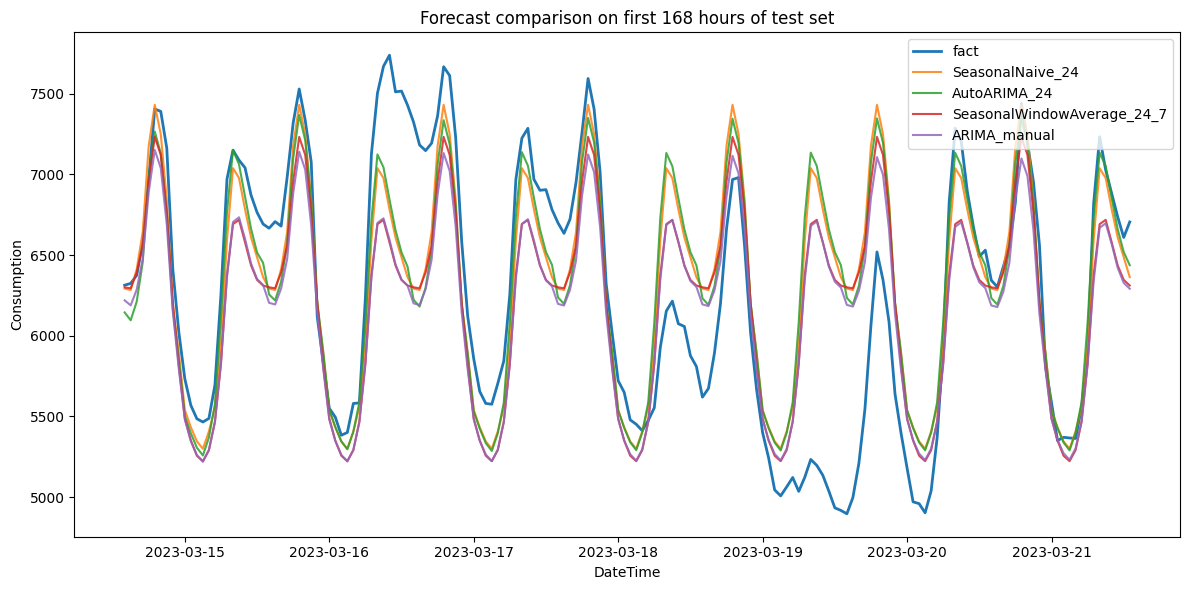

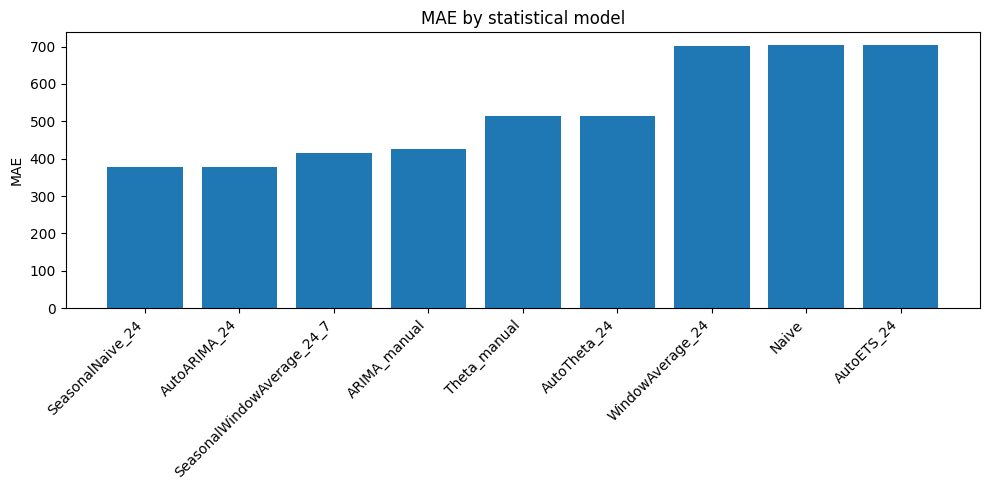

In [ ]:
best_model = metrics_df.iloc[0]['model']

plt.figure(figsize=(12, 6))
plt.plot(forecast_df['ds'], forecast_df['y_true'], label='fact', linewidth=2)
for m in list(metrics_df['model'].head(4)):
    plt.plot(forecast_df['ds'], forecast_df[m], label=m, alpha=.85)
plt.title('Forecast comparison on first 168 hours of test set')
plt.xlabel('DateTime')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'task2_forecast_comparison_h168.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(metrics_df['model'], metrics_df['MAE'])
plt.xticks(rotation=45, ha='right')
plt.title('MAE by statistical model')
plt.ylabel('MAE')
plt.tight_layout()
plt.savefig(FIGURES / 'task2_model_mae.png', dpi=150)
plt.show()

### Вывод по графикам

На графике прогноза видно, что лучшие модели в целом повторяют суточный профиль потребления: дневные пики и ночные снижения. Это подтверждает наличие выраженной суточной сезонности, которая была выявлена ещё на этапе EDA.

Модели SeasonalNaive_24 и AutoARIMA_24 визуально ближе всего расположены к фактическому ряду на большей части тестового участка. При этом в отдельные периоды фактические значения заметно отклоняются от прогнозов, особенно в районе резких спадов и подъёмов, что показывает, что даже лучшие статистические модели не полностью описывают все колебания ряда.

Столбчатый график MAE подтверждает численные результаты сравнения моделей. Минимальную ошибку имеет SeasonalNaive_24, очень близкий результат показывает AutoARIMA_24. Модели WindowAverage_24, Naive и AutoETS_24 имеют самые большие значения MAE, поэтому их качество хуже.

Таким образом, графики подтверждают результаты таблицы метрик. Для данного временного ряда наиболее удачными среди рассмотренных статистических моделей являются SeasonalNaive_24 и AutoARIMA_24, однако наличие заметных расхождений на отдельных участках показывает, что качество прогноза ещё можно улучшать на следующих этапах работы.

## 10. Итоговые выводы

В рамках задачи №2 были рассмотрены статистические методы прогнозирования временного ряда потребления электроэнергии с использованием фреймворка StatsForecast. Для работы использовались подготовленные обучающая и тестовая выборки, полученные на этапе задачи №1. Повторные очистка данных и разбиение на train/test в этой задаче не выполнялись.

Целью задачи было сравнить несколько статистических моделей прогнозирования временного ряда, включая ручные модели и модели с автоматическим подбором параметров. Для сравнения были использованы следующие методы:

- Naive;
- SeasonalNaive_24;
- WindowAverage_24;
- SeasonalWindowAverage_24_7;
- ARIMA_manual;
- Theta_manual;
- AutoETS_24;
- AutoTheta_24;
- AutoARIMA_24.

Таким образом, всего было рассмотрено 9 моделей. В сравнение вошли как простые бейзлайны, так и статистические модели ARIMA, ETS и Theta в ручном и автоматическом режимах.

Для почасового временного ряда была задана суточная сезонность season_length=24, так как на этапе EDA в задаче №1 была выявлена выраженная зависимость потребления электроэнергии от времени суток.

По результатам сравнения на финальном тестовом участке лучшей моделью по основной метрике MAE стала SeasonalNaive_24. Она показала MAE = 377.52, RMSE = 539.29, sMAPE = 6.06% и MASE = 0.94. Очень близкий результат показала модель AutoARIMA_24: MAE = 378.52, RMSE = 545.50, sMAPE = 6.09% и MASE = 0.95. Это показывает, что автоматический подбор ARIMA-параметров дал качество, сопоставимое с простым сезонным бейзлайном, но не обеспечил существенного улучшения.

Результаты бектестинга показали, что нескольких скользящих окнах обучающей выборки лучшей оказалась модель SeasonalWindowAverage_24_7, которая показала MAE = 435.71 и sMAPE = 7.28%. Это означает, что модель сезонного скользящего среднего оказалась более устойчивой на разных временных участках обучающей выборки, чем SeasonalNaive_24.

Вероятностный прогноз был построен для модели SeasonalNaive_24, так как она показала лучшее качество на финальном тестовом участке. Были рассчитаны интервалы 80% и 95%, которые позволяют оценить неопределённость прогноза. Интервал 95% шире интервала 80%, поэтому он охватывает больший диапазон возможных будущих значений.

Анализ остатков подтвердил, что SeasonalNaive_24 и AutoARIMA_24 являются лучшими моделями среди рассмотренных по величине ошибки и смещению остатков. Однако остатки этих моделей нельзя считать полностью случайными: автокорреляция на лаге 24 остаётся заметной, а p-value теста Ljung-Box очень мало. Это означает, что в остатках сохраняется часть суточной структуры, которую модели не полностью объясняют.

Итоговый выбор модели зависит от критерия. Если ориентироваться на качество на финальном тестовом участке, наиболее удачной моделью является SeasonalNaive_24. Если учитывать устойчивость на скользящих окнах, более предпочтительной кажется модель SeasonalWindowAverage_24_7. В качестве конкурентной статистической модели также можно рассматривать AutoARIMA_24, так как её качество почти совпадает с результатом лучшей модели на тестовой выборке.